<a href="https://colab.research.google.com/github/Royst97/DSRP_Roy/blob/main/DSRP_2026_Royston.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Stuff:

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score, auc


In [2]:
df = pd.read_csv("/content/lendingclub_loans_export.csv")

Exploring the Data:

In [3]:
print(df.dtypes, "\n")
print(df.info())

emp_title                            object
emp_length                          float64
state                                object
homeownership                        object
annual_income                       float64
verified_income                      object
debt_to_income                      float64
annual_income_joint                 float64
verification_income_joint            object
debt_to_income_joint                float64
delinq_2y                             int64
months_since_last_delinq            float64
earliest_credit_line                  int64
inquiries_last_12m                    int64
total_credit_lines                    int64
open_credit_lines                     int64
total_credit_limit                    int64
total_credit_utilized                 int64
num_collections_last_12m              int64
num_historical_failed_to_pay          int64
months_since_90d_late               float64
current_accounts_delinq               int64
total_collection_amount_ever    

In [4]:
print(df.shape, "\n")
print(df.columns)

(10000, 55) 

Index(['emp_title', 'emp_length', 'state', 'homeownership', 'annual_income',
       'verified_income', 'debt_to_income', 'annual_income_joint',
       'verification_income_joint', 'debt_to_income_joint', 'delinq_2y',
       'months_since_last_delinq', 'earliest_credit_line',
       'inquiries_last_12m', 'total_credit_lines', 'open_credit_lines',
       'total_credit_limit', 'total_credit_utilized',
       'num_collections_last_12m', 'num_historical_failed_to_pay',
       'months_since_90d_late', 'current_accounts_delinq',
       'total_collection_amount_ever', 'current_installment_accounts',
       'accounts_opened_24m', 'months_since_last_credit_inquiry',
       'num_satisfactory_accounts', 'num_accounts_120d_past_due',
       'num_accounts_30d_past_due', 'num_active_debit_accounts',
       'total_debit_limit', 'num_total_cc_accounts', 'num_open_cc_accounts',
       'num_cc_carrying_balance', 'num_mort_accounts',
       'account_never_delinq_percent', 'tax_liens', 'publi

Cleaning the Data:

In [5]:
#Change NA values to null
df = df.replace("NA", np.nan)

#All loans were 2018, remove year from issue month
df["issue_month"] = pd.to_datetime(df["issue_month"], format="%b-%Y").dt.strftime

#Grade information included in subgrade
df.drop(columns = ["grade"], inplace = True)

#Dropping columns with excessive null values and do not pertain to my research
df = df.drop(columns=["annual_income_joint","verification_income_joint","debt_to_income_joint","months_since_last_delinq","months_since_90d_late"])

#Makes a new column to help easier classify whether or not a loaner has had a delinquency
df["had_delinquency"] = df["delinq_2y"] > 0

#Dropping some rows with null values
df = df.dropna(subset=["debt_to_income"])



In [6]:
#Checking for duplicates
print(df.duplicated().sum(), "\n")

print(df.info())

0 

<class 'pandas.core.frame.DataFrame'>
Index: 9976 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   emp_title                         9166 non-null   object 
 1   emp_length                        9182 non-null   float64
 2   state                             9976 non-null   object 
 3   homeownership                     9976 non-null   object 
 4   annual_income                     9976 non-null   float64
 5   verified_income                   9976 non-null   object 
 6   debt_to_income                    9976 non-null   float64
 7   delinq_2y                         9976 non-null   int64  
 8   earliest_credit_line              9976 non-null   int64  
 9   inquiries_last_12m                9976 non-null   int64  
 10  total_credit_lines                9976 non-null   int64  
 11  open_credit_lines                 9976 non-null   int64  
 12  total_c

Visuals

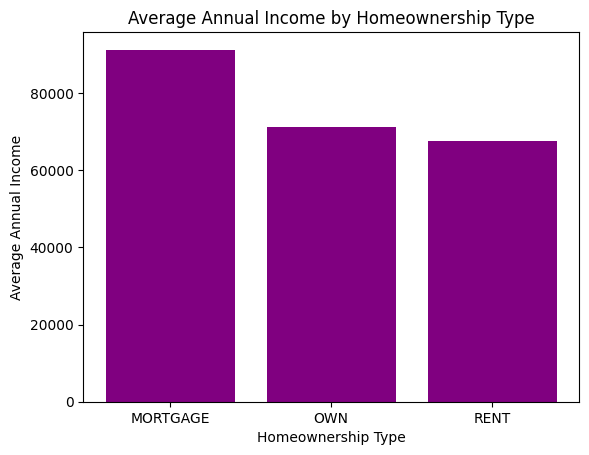

In [7]:
#I might want to do a question based on house ownership compared to something else so this visual is in preparation


avg_anninc = df.groupby("homeownership")["annual_income"].mean()

plt.bar(avg_anninc.index, avg_anninc.values, color="purple")
plt.title("Average Annual Income by Homeownership Type")
plt.xlabel("Homeownership Type")
plt.ylabel("Average Annual Income")

plt.show()

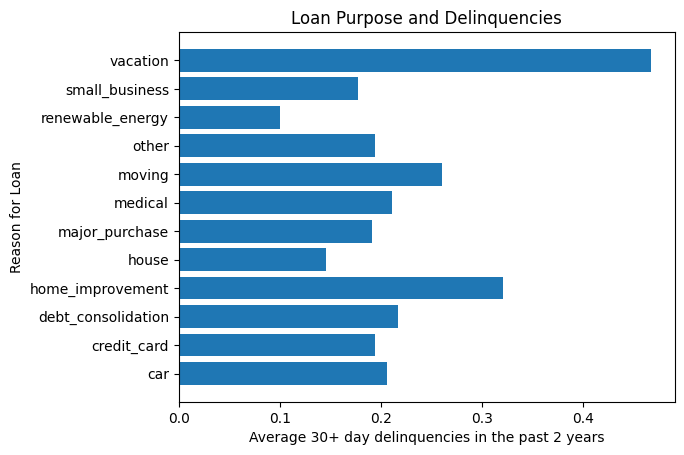

In [8]:
avg_delinq = df.groupby("loan_purpose")["delinq_2y"].mean()

plt.barh(avg_delinq.index, avg_delinq.values)
plt.title("Loan Purpose and Delinquencies")
plt.xlabel("Average 30+ day delinquencies in the past 2 years")
plt.ylabel("Reason for Loan")

plt.show()

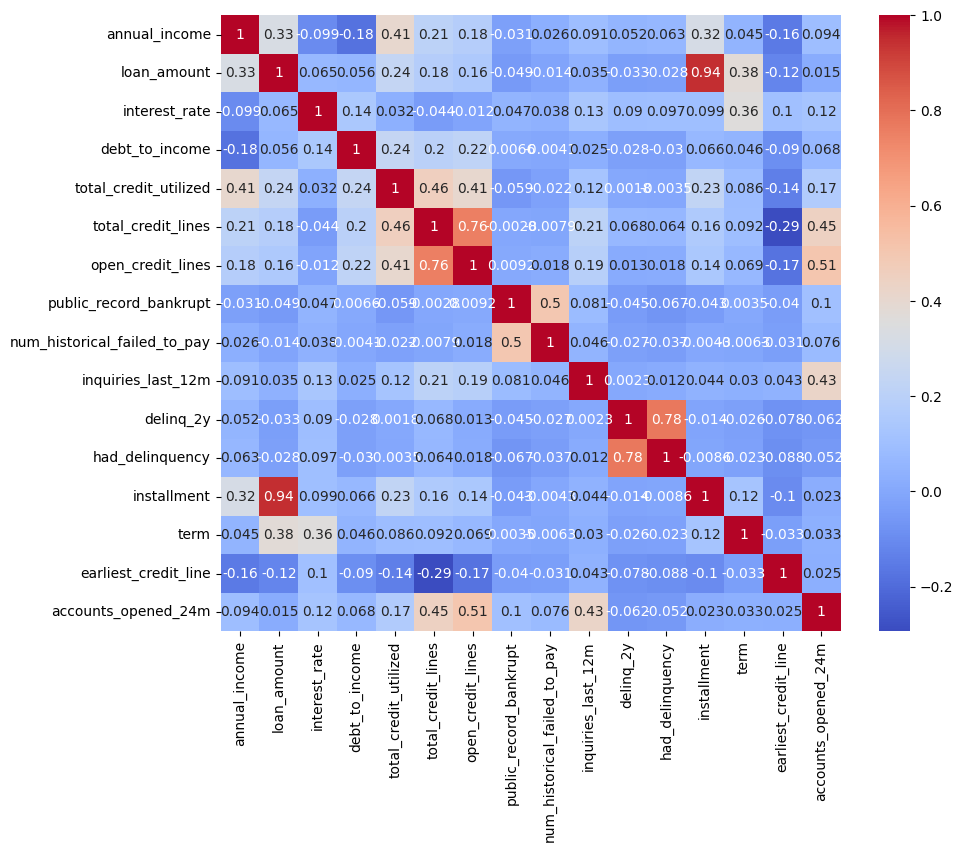

In [59]:
corr = df[
    [
        "annual_income",
        "loan_amount",
        "interest_rate",
        "debt_to_income",
        "total_credit_utilized",
        "total_credit_lines",
        "open_credit_lines",
        "public_record_bankrupt",
        "num_historical_failed_to_pay",
        "inquiries_last_12m",
        "delinq_2y",
        "had_delinquency",
        "installment",
        "term",
        "earliest_credit_line",
        "accounts_opened_24m"
    ]
].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

Making the Machine Learning Models

In [46]:
#making dependant and independant variables
x = df[["annual_income",
               "loan_amount",
               "interest_rate",
               "debt_to_income",
               "total_credit_utilized",
               "total_credit_lines",
               "open_credit_lines",
               "public_record_bankrupt",
               "num_historical_failed_to_pay",
               "inquiries_last_12m","tax_liens"]]

y = df["had_delinquency"]

In [47]:
#Splitting the data into training and test parts
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 67, stratify=y)

In [48]:
#Creating the models
model_lr = LogisticRegression(class_weight='balanced')
model_rf = RandomForestClassifier(class_weight='balanced', random_state = 67)
model_svm = SVC(class_weight='balanced')

In [49]:
#Training the models
model_lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced')

In [50]:
model_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=67)

In [51]:
model_svm.fit(X_train, y_train)

SVC(class_weight='balanced')

In [52]:
pred_lr = model_lr.predict(X_test)
pred_rf = model_rf.predict(X_test)
pred_svm = model_svm.predict(X_test)

Looking at Model metrics to determine the best one:

In [53]:
print("Logistic Regression:", accuracy_score(y_test, pred_lr))
print("Random Forest:", accuracy_score(y_test, pred_rf))
print("SVM:", accuracy_score(y_test, pred_svm), "\n")

print("Logistic Regression")
print(confusion_matrix(y_test, pred_lr))

print("\nRandom Forest")
print(confusion_matrix(y_test, pred_rf))

print("\nSupport Vector Machine")
print(confusion_matrix(y_test, pred_svm))

Logistic Regression: 0.5130260521042084
Random Forest: 0.8557114228456913
SVM: 0.6287575150300602 

Logistic Regression
[[843 869]
 [103 181]]

Random Forest
[[1706    6]
 [ 282    2]]

Support Vector Machine
[[1112  600]
 [ 141  143]]


In [61]:
model_rf.predict_proba(x)

array([[0.86, 0.14],
       [0.92, 0.08],
       [0.8 , 0.2 ],
       ...,
       [0.18, 0.82],
       [0.92, 0.08],
       [0.96, 0.04]])

In [30]:
prediction = model_rf.predict(pd.DataFrame([[120000, 10000, 6.5, 12.0, 12000, 18, 15, 0, 0, 0]],
                         columns=["annual_income","loan_amount","interest_rate", "debt_to_income", "total_credit_utilized","total_credit_lines", "open_credit_lines", "public_record_bankrupt", "num_historical_failed_to_pay", "inquiries_last_12m",]))

prediction

array([False])

Random forest Visualizations:

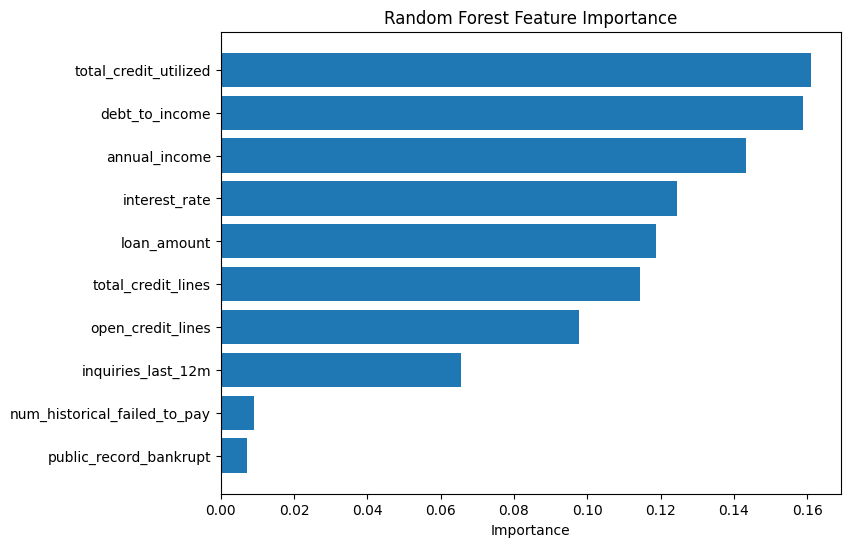

In [ ]:
importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": model_rf.feature_importances_
})

importance = importance.sort_values("Importance", ascending=True)

plt.figure(figsize=(8,6))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()